# Digits: PCA + Perceptron in a Pipeline with GridSearch

Exercise notebook:
- Load a local `digit.csv` file (expects features + a label column).
- Apply PCA as dimensionality reduction.
- Train a Perceptron classifier.
- Use Pipeline and  GridSearchCV to find best hyperparameters.
- Evaluate on a held-out test set and show a few visualizations (explained variance, 2D PCA projection, confusion matrix).


In [70]:
# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount("/content/drive",force_remount=True)
path="/content/drive/My Drive/data/digit.csv"


Mounted at /content/drive


In [71]:
# 1) Load digit.csv (assumes file is in the notebook working directory)
df = pd.read_csv(path)
print('Loaded shape:', df.shape)
df.head()

Loaded shape: (499, 785)


,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.10,0.11,0.12,0.13,0.14,0.15,0.16,0.17,0.18,0.19,0.20,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.30,0.31,0.32,0.33,0.34,0.35,0.36,0.37,0.38,0.39,...,0.569,0.570,0.571,0.572,0.573,0.574,0.575,0.576,0.577,0.578,0.579,0.580,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590,0.591,0.592,0.593,0.594,0.595,0.596,0.597,0.598,0.599,0.600,0.601,0.602,0.603,0.604,0.605,0.606,0.607,0.608
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Split the data into train / test (hold out test set as a locked box). We will run GridSearchCV on the training portion (For validation).

In [72]:
# 3) Train/Test split
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y)


Build a pipeline: StandardScaler -> PCA -> Perceptron. We keep PCA as a named step so we can grid-search n_components and later inspect explained variance.

In [73]:
# 4) Pipeline definition
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.decomposition import PCA
steps = [("scale",StandardScaler()),
         ("pca", PCA()),
         ("clf", Perceptron())]

pipe = Pipeline(steps)

Set up a small parameter grid  
- pca__n_components: try a few dimensionalities (Remember the real size is 28*28)
- Use  few pameter from clssfiction


In [74]:
# 5) Parameter grid
param_grid = {
    'pca__n_components': [10, 30, 50],
    'clf__eta0': [0.0001, 0.001, 0.01], # if perceptron define as clf
    'clf__max_iter' : [50,150,1000],
 #add more parameter
}
param_grid

{'pca__n_components': [10, 30, 50],
 'clf__eta0': [0.0001, 0.001, 0.01],
 'clf__max_iter': [50, 150, 1000]}

Run GridSearchCV with StratifiedKFold/or CrossValidationKfold (fold 4-7 of your chose) on the training data. The search will fit preprocessing inside each fold because we used a Pipeline.

In [75]:
# 6) Grid search
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(pipe, param_grid, scoring = "accuracy", cv = 5)
gs.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scale', StandardScaler()),
                                       ('pca', PCA()), ('clf', Perceptron())]),
             param_grid={'clf__eta0': [0.0001, 0.001, 0.01],
                         'clf__max_iter': [50, 150, 1000],
                         'pca__n_components': [10, 30, 50]},
             scoring='accuracy')

Inspect a small summary of cv_results_.

In [76]:
# 7) Inspect results (compact)
import pandas as pd
results = pd.DataFrame(gs.cv_results_)
cols = ['param_pca__n_components', 'param_clf__eta0',  'mean_test_score', 'std_test_score', 'rank_test_score']# add more parameter as needed
display(results[cols].sort_values('rank_test_score').head(10))


,param_pca__n_components,param_clf__eta0,mean_test_score,std_test_score,rank_test_score
26,50,0.0100,0.770018,0.019988,1
17,50,0.0010,0.762054,0.009380,2
23,50,0.0100,0.756793,0.024970,3
20,50,0.0100,0.756757,0.014467,4
11,50,0.0010,0.754054,0.019413,5
14,50,0.0010,0.745874,0.029123,6
8,50,0.0001,0.743171,0.047418,7
25,30,0.0100,0.732613,0.012012,8
1,30,0.0001,0.724649,0.031794,9
4,30,0.0001,0.722090,0.034130,10


Evaluate the best estimator on the held-out test set (one-time evaluation).

best estimatorPipeline(steps=[('scale', StandardScaler()), ('pca', PCA(n_components=50)),
                ('clf', Perceptron(eta0=0.01))])


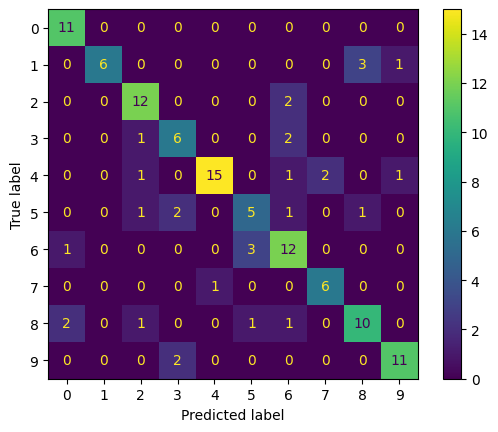

[[11  0  0  0  0  0  0  0  0  0]
 [ 0  6  0  0  0  0  0  0  3  1]
 [ 0  0 12  0  0  0  2  0  0  0]
 [ 0  0  1  6  0  0  2  0  0  0]
 [ 0  0  1  0 15  0  1  2  0  1]
 [ 0  0  1  2  0  5  1  0  1  0]
 [ 1  0  0  0  0  3 12  0  0  0]
 [ 0  0  0  0  1  0  0  6  0  0]
 [ 2  0  1  0  0  1  1  0 10  0]
 [ 0  0  0  2  0  0  0  0  0 11]]


In [77]:
# 8) Final evaluation on test set
# Best Estimator
# Test on the test set
#Show confusion matrix
#Plot the loss value
#ROC is
from sklearn.metrics import ConfusionMatrixDisplay, classification_report,confusion_matrix

best = gs.best_estimator_
print(f"best estimator{best}")
y_pred = gs.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print(cm)

In [101]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      1.00      0.88        11
           1       1.00      0.60      0.75        10
           2       0.75      0.86      0.80        14
           3       0.60      0.67      0.63         9
           4       0.94      0.75      0.83        20
           5       0.56      0.50      0.53        10
           6       0.63      0.75      0.69        16
           7       0.75      0.86      0.80         7
           8       0.71      0.67      0.69        15
           9       0.85      0.85      0.85        13

    accuracy                           0.75       125
   macro avg       0.76      0.75      0.74       125
weighted avg       0.77      0.75      0.75       125



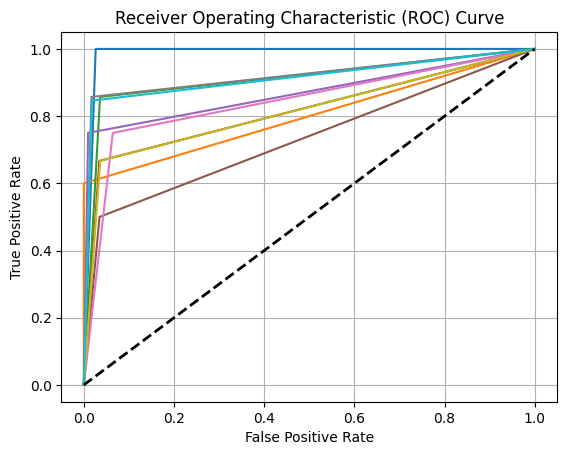

In [90]:
# ROC
from sklearn.metrics import roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

y_test_bin, y_pred_bin = [],[]
fpr, tpr = [None]*10,[None]*10 # Initialize with None
for i in range(10):
  y_test_bin.append(1 * (y_test == i))
  y_pred_bin.append(1 * (y_pred == i))

for i in range(10):
  fpr[i], tpr[i], _ = roc_curve(y_test_bin[i], y_pred_bin[i])


for i in range(10):
  plt.plot(fpr[i], tpr[i], label=f'Class {i}')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance') # Plot the diagonal chance line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.grid(True)
plt.show()

Examine the PCA explained variance for the selected PCA step. The pipeline was refit on the full training data by GridSearchCV (refit=True), so we can inspect the PCA inside the best estimator.

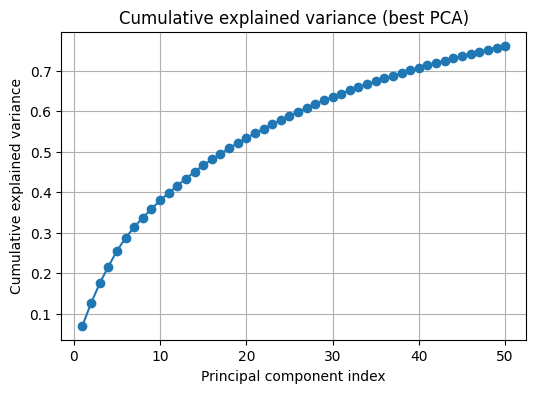

Number of components used by best PCA: 50


In [79]:
# 9) PCA explained variance (from best estimator)
best_pca = best.named_steps['pca']
explained = best_pca.explained_variance_ratio_
cumvar = np.cumsum(explained)
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(explained)+1), cumvar, marker='o')
plt.xlabel('Principal component index')
plt.ylabel('Cumulative explained variance')
plt.title('Cumulative explained variance (best PCA)')
plt.grid(True)
plt.show()

print('Number of components used by best PCA:', best_pca.n_components_)


์Show the loss progression

In [80]:
"""
#Plot the loss function
#name the best parameter and consider the fit

#pipe.fit(X, y)
mlp = best.named_steps['clf']

# training loss per iteration
plt.plot(mlp.loss_curve_, marker='o')
plt.xlabel('Epoch/Iteration')
plt.ylabel('Training loss')
plt.title('MLP training loss curve')
plt.grid(True)
plt.show()
"""

"\n#Plot the loss function\n#name the best parameter and consider the fit\n\n#pipe.fit(X, y)\nmlp = best.named_steps['clf']\n\n# training loss per iteration\nplt.plot(mlp.loss_curve_, marker='o')\nplt.xlabel('Epoch/Iteration')\nplt.ylabel('Training loss')\nplt.title('MLP training loss curve')\nplt.grid(True)\nplt.show()\n"

Visualize a 2D PCA projection of the test set (using the scaler + PCA steps from the fitted pipeline). This helps see class separation in reduced space.

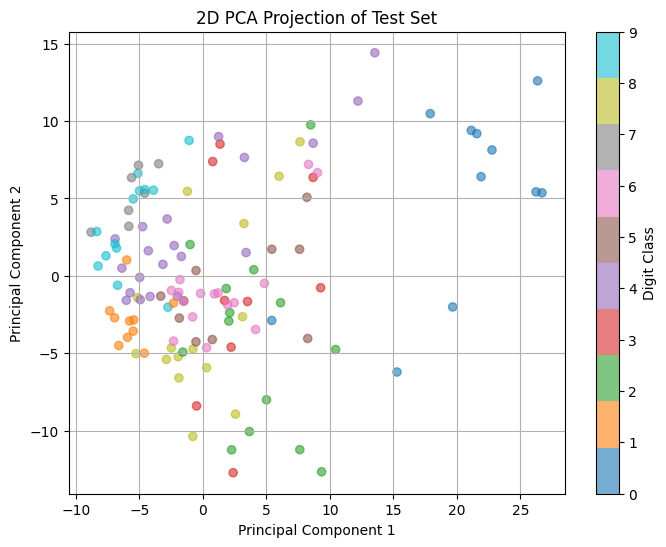

In [86]:
# 10) 2D projection (if PCA has >=2 components)
scaler = best.named_steps['scale']
pca = best.named_steps['pca']

X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

if X_test_pca.shape[1] >= 2:
  plt.figure(figsize=(8, 6))
  scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='tab10', alpha=0.6)
  plt.xlabel('Principal Component 1')
  plt.ylabel('Principal Component 2')
  plt.title('2D PCA Projection of Test Set')
  plt.colorbar(scatter, label='Digit Class')
  plt.grid(True)
  plt.show()


-Try remove PCA step and detect the best

In [95]:
steps2 = [("scaler", StandardScaler()),
          ("clf", Perceptron())]
param_grid2 = {
    'clf__eta0': [0.0001, 0.001, 0.01], # if perceptron define as clf
    'clf__max_iter' : [50,150,1000],
 #add more parameter
}

pipe2 = Pipeline(steps2)

In [99]:
gs2 = GridSearchCV(pipe2,param_grid=param_grid2,cv=5)
gs2.fit(X_train, y_train)
y_pred2 = gs2.predict(X_test)

In [100]:
print(classification_report(y_pred2, y_test))

              precision    recall  f1-score   support

           0       1.00      0.85      0.92        13
           1       0.90      0.90      0.90        10
           2       0.86      0.71      0.77        17
           3       0.44      0.44      0.44         9
           4       0.65      0.81      0.72        16
           5       0.50      0.45      0.48        11
           6       0.94      0.88      0.91        17
           7       0.86      0.55      0.67        11
           8       0.47      0.88      0.61         8
           9       0.77      0.77      0.77        13

    accuracy                           0.74       125
   macro avg       0.74      0.72      0.72       125
weighted avg       0.76      0.74      0.74       125



Quick Note.....